# WBM Prediction Diagnosis

Diagnoses false positives and error structure across four prediction sets:
- Baseline (200ep, seed=0) — mean-TTA
- Baseline (200ep, seed=0) — min-TTA
- Stage A (500ep, EMA-0.999) — mean-TTA
- Stage A (500ep, EMA-0.999) — min-TTA

Dataset needed ::: `predictions_wbm.csv` files and `wbm-summary.csv.gz` — no model weights needed.

## Section 1 — Setup and data loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pymatgen.core import Composition

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 120,
})

BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'
GREY   = '#8C8C8C'

REPO_ROOT = Path('..').resolve()
OUT_DIR   = REPO_ROOT / 'results' / 'diagnosis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Hull threshold for stability (eV/atom)
HULL_THRESHOLD = 0.0

In [2]:
# --- Load WBM ground truth ---
summary = pd.read_csv(REPO_ROOT / 'data' / 'raw' / 'wbm-summary.csv.gz')
print(f'WBM summary: {len(summary):,} rows')
print(f'Columns: {list(summary.columns)}')

WBM summary: 256,963 rows
Columns: ['material_id', 'formula', 'n_sites', 'volume', 'uncorrected_energy', 'e_form_per_atom_wbm', 'e_above_hull_wbm', 'bandgap_pbe', 'wyckoff_spglib_initial_structure', 'uncorrected_energy_from_cse', 'e_correction_per_atom_mp2020', 'e_correction_per_atom_mp_legacy', 'e_form_per_atom_uncorrected', 'e_form_per_atom_mp2020_corrected', 'e_above_hull_mp2020_corrected_ppd_mp', 'site_stats_fingerprint_init_final_norm_diff', 'wyckoff_spglib', 'unique_prototype']


In [3]:
# --- Load four prediction files ---
pred_paths = {
    'baseline_mean' : REPO_ROOT / 'runs' / 'default'  / 'predictions_wbm.csv',
    'baseline_min'  : REPO_ROOT / 'runs' / 'default'  / 'min_tta' / 'predictions_wbm.csv',
    'stageA_mean'   : REPO_ROOT / 'runs' / 'stage_a'  / 'predictions_wbm.csv',
    'stageA_min'    : REPO_ROOT / 'runs' / 'stage_a'  / 'min_tta' / 'predictions_wbm.csv',
}

preds = {}
for name, path in pred_paths.items():
    if path.exists():
        preds[name] = pd.read_csv(path)
        print(f'{name:20s}: {len(preds[name]):,} rows  ({path})')
    else:
        print(f'{name:20s}: FILE NOT FOUND — {path}')

baseline_mean       : 256,963 rows  (E:\Projects\gnome-repro-structural\runs\default\predictions_wbm.csv)
baseline_min        : 256,963 rows  (E:\Projects\gnome-repro-structural\runs\default\min_tta\predictions_wbm.csv)
stageA_mean         : 256,963 rows  (E:\Projects\gnome-repro-structural\runs\stage_a\predictions_wbm.csv)
stageA_min          : 256,963 rows  (E:\Projects\gnome-repro-structural\runs\stage_a\min_tta\predictions_wbm.csv)


In [4]:
# --- Build merged dataframes ---
# Keep columns we need from summary
keep_cols = [
    'material_id',
    'formula',
    'n_sites',
    'e_form_per_atom_wbm',
    'e_above_hull_wbm',
    'bandgap_pbe',
]
# Add optional columns if present
for col in ['wyckoff_spglib', 'unique_prototype']:
    if col in summary.columns:
        keep_cols.append(col)

gt = summary[keep_cols].copy()

# Parse n_unique_elements from formula
def n_unique_elements(formula_str):
    try:
        return len(Composition(formula_str).elements)
    except Exception:
        return np.nan

gt['n_unique_elements'] = gt['formula'].apply(n_unique_elements)
gt['true_stable']       = gt['e_above_hull_wbm'] <= HULL_THRESHOLD

# Merge each prediction set
merged = {}
for name, df in preds.items():
    m = df.merge(gt, on='material_id', how='inner')
    m = m.dropna(subset=['e_form_pred', 'e_form_per_atom_wbm'])
    m['error']         = m['e_form_pred'] - m['e_form_per_atom_wbm']   # signed error
    m['abs_error']     = m['error'].abs()
    m['pred_stable']   = m['e_form_pred'] <= HULL_THRESHOLD
    m['tp'] = m['pred_stable'] & m['true_stable']
    m['fp'] = m['pred_stable'] & ~m['true_stable']
    m['fn'] = ~m['pred_stable'] & m['true_stable']
    m['tn'] = ~m['pred_stable'] & ~m['true_stable']
    merged[name] = m
    tp = m['tp'].sum(); fp = m['fp'].sum()
    fn = m['fn'].sum(); tn = m['tn'].sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f'{name:20s}: F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}  '
          f'TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')

print(f'\nN truly stable : {gt["true_stable"].sum():,} / {len(gt):,}')

baseline_mean       : F1=0.3645  P=0.2248  R=0.9637  TP=46,524  FP=160,468  FN=1,752  TN=48,195
baseline_min        : F1=0.3436  P=0.2077  R=0.9930  TP=47,937  FP=182,816  FN=339  TN=25,847
stageA_mean         : F1=0.3631  P=0.2234  R=0.9697  TP=46,811  FP=162,732  FN=1,465  TN=45,931
stageA_min          : F1=0.3432  P=0.2074  R=0.9930  TP=47,936  FP=183,161  FN=340  TN=25,502

N truly stable : 48,276 / 256,963


## Section 2 — Error distribution

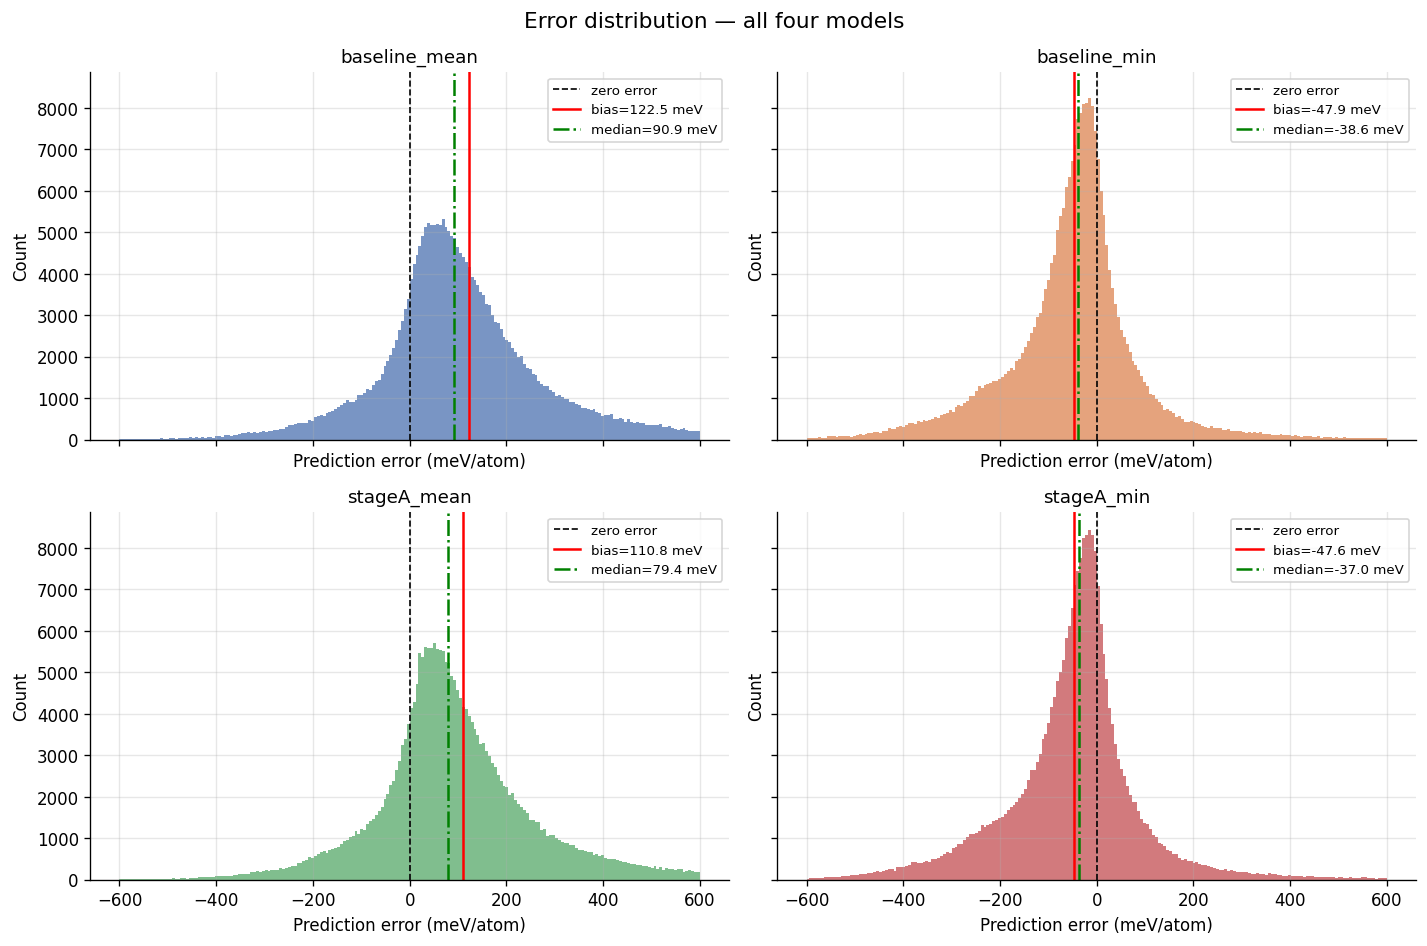

Saved: 01_error_distribution.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
colors = [BLUE, ORANGE, GREEN, RED]

for ax, (name, m), color in zip(axes.flat, merged.items(), colors):
    errors = m['error'] * 1000  # meV/atom
    ax.hist(errors, bins=200, range=(-600, 600), color=color, alpha=0.75)
    ax.axvline(0,               color='black', lw=1,   ls='--', label='zero error')
    ax.axvline(errors.mean(),   color='red',   lw=1.5, ls='-',  label=f'bias={errors.mean():.1f} meV')
    ax.axvline(errors.median(), color='green', lw=1.5, ls='-.',  label=f'median={errors.median():.1f} meV')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('Prediction error (meV/atom)')
    ax.set_ylabel('Count')

fig.suptitle('Error distribution — all four models', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '01_error_distribution.png', dpi=150)
plt.show()
print('Saved: 01_error_distribution.png')

In [6]:
# Tail analysis — what fraction of structures have |error| > threshold?
thresholds = [100, 200, 300, 500]  # meV/atom
rows = []
for name, m in merged.items():
    ae = m['abs_error'] * 1000
    row = {'model': name, 'MAE': ae.mean(), 'RMSE': np.sqrt((ae**2).mean()), 'bias': (m['error']*1000).mean()}
    for t in thresholds:
        row[f'>|{t}|meV_%'] = round(100 * (ae > t).mean(), 2)
    rows.append(row)

tail_df = pd.DataFrame(rows).set_index('model').round(2)
print('\nError tail analysis:')
display(tail_df)


Error tail analysis:


,MAE,RMSE,bias,>|100|meV_%,>|200|meV_%,>|300|meV_%,>|500|meV_%
model,,,,,,,
baseline_mean,168.76,253.94,122.48,55.63,27.82,14.72,5.09
baseline_min,110.25,171.79,-47.87,36.41,16.52,7.46,1.63
stageA_mean,159.93,244.88,110.81,52.42,25.61,13.46,4.63
stageA_min,109.40,169.98,-47.65,36.51,16.47,7.30,1.60


## Section 3 — False positive characterisation

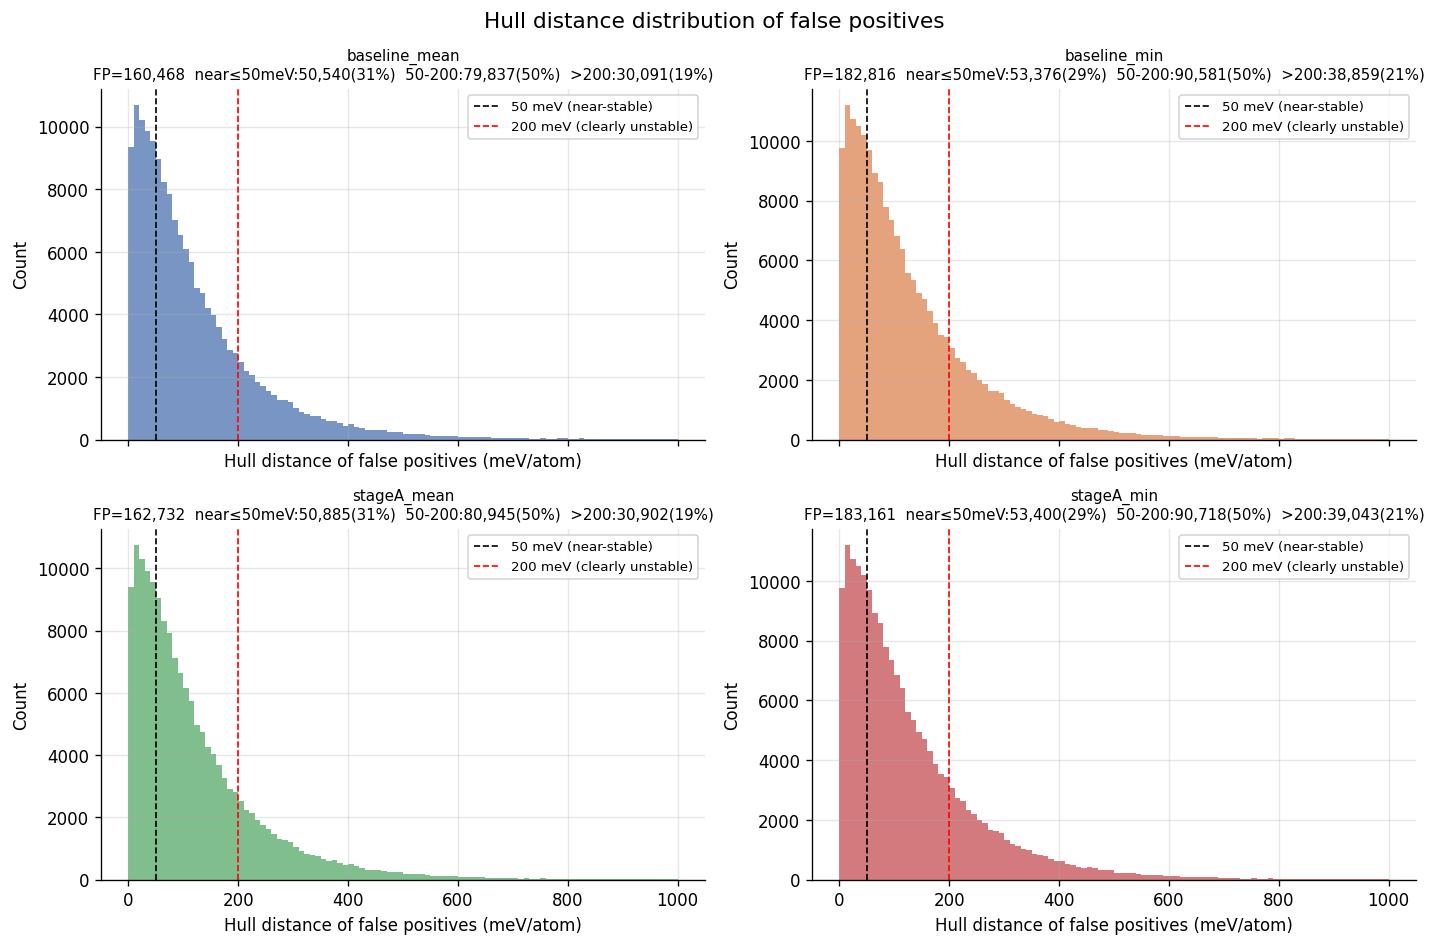

Saved: 02_fp_hull_distribution.png


In [7]:
# Hull distance distribution of false positives
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Bin boundaries for hull distance (eV/atom)
bins = np.linspace(0, 1.0, 51)

for ax, (name, m), color in zip(axes.flat, merged.items(), colors):
    fp_hull = m.loc[m['fp'], 'e_above_hull_wbm'] * 1000  # meV/atom
    ax.hist(fp_hull, bins=100, range=(0, 1000), color=color, alpha=0.75)
    ax.axvline(50,  color='black', lw=1, ls='--', label='50 meV (near-stable)')
    ax.axvline(200, color='red',   lw=1, ls='--', label='200 meV (clearly unstable)')
    near  = (fp_hull <= 50).sum()
    mid   = ((fp_hull > 50) & (fp_hull <= 200)).sum()
    far   = (fp_hull > 200).sum()
    total = len(fp_hull)
    ax.set_title(f'{name}\nFP={total:,}  near≤50meV:{near:,}({100*near/max(total,1):.0f}%)  '
                 f'50-200:{mid:,}({100*mid/max(total,1):.0f}%)  >200:{far:,}({100*far/max(total,1):.0f}%)',
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlabel('Hull distance of false positives (meV/atom)')
    ax.set_ylabel('Count')

fig.suptitle('Hull distance distribution of false positives', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '02_fp_hull_distribution.png', dpi=150)
plt.show()
print('Saved: 02_fp_hull_distribution.png')

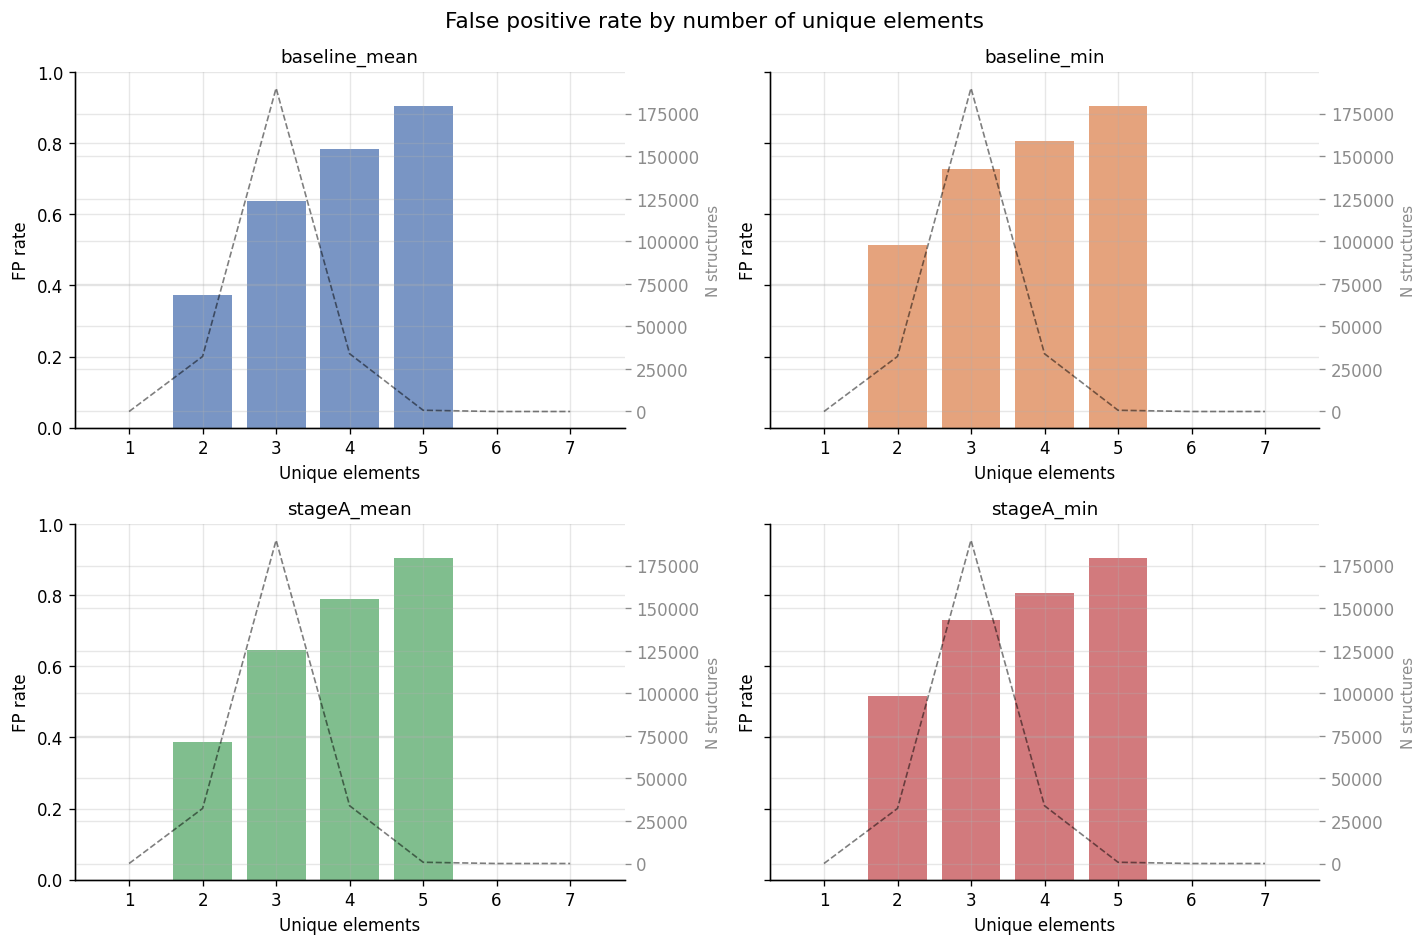

Saved: 03_fp_by_nelements.png


In [8]:
# FP rate by number of unique elements
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (name, m), color in zip(axes.flat, merged.items(), colors):
    elem_range = range(1, 8)
    fp_rates, counts = [], []
    for n in elem_range:
        sub = m[m['n_unique_elements'] == n]
        if len(sub) == 0:
            fp_rates.append(0); counts.append(0)
            continue
        fp_rates.append(sub['fp'].sum() / len(sub))
        counts.append(len(sub))
    ax.bar(list(elem_range), fp_rates, color=color, alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(list(elem_range), counts, 'k--', lw=1, alpha=0.5, label='N structures')
    ax2.set_ylabel('N structures', color=GREY, fontsize=9)
    ax2.tick_params(axis='y', colors=GREY)
    ax.set_xlabel('Unique elements')
    ax.set_ylabel('FP rate')
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(list(elem_range))

fig.suptitle('False positive rate by number of unique elements', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '03_fp_by_nelements.png', dpi=150)
plt.show()
print('Saved: 03_fp_by_nelements.png')

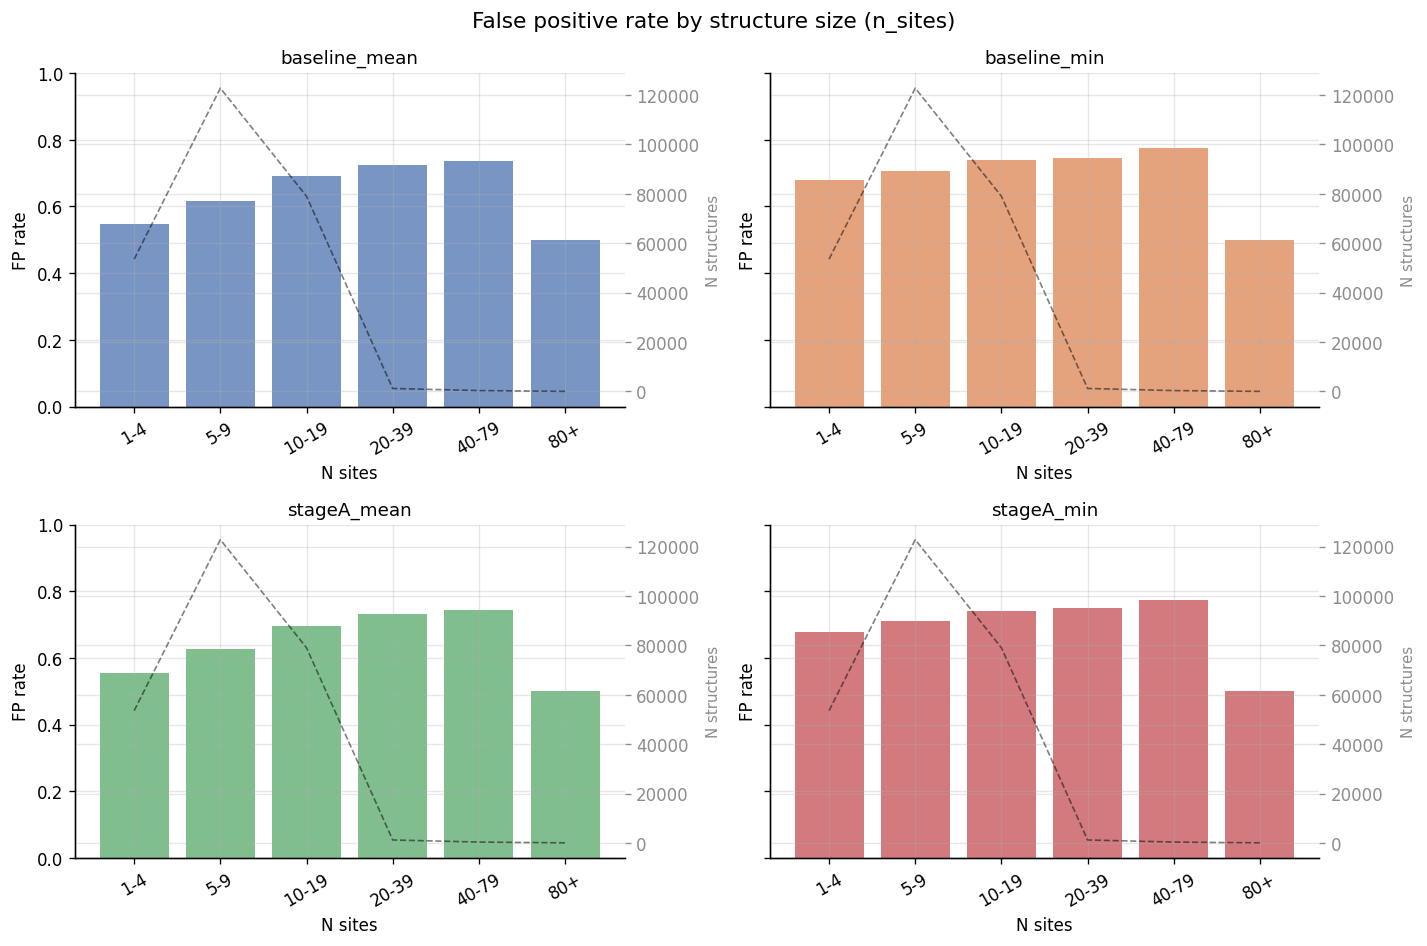

Saved: 04_fp_by_nsites.png


In [9]:
# FP rate by n_sites (structure size)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

size_bins = [1, 5, 10, 20, 40, 80, 200]
size_labels = ['1-4', '5-9', '10-19', '20-39', '40-79', '80+']

for ax, (name, m), color in zip(axes.flat, merged.items(), colors):
    m = m.copy()
    m['size_bin'] = pd.cut(m['n_sites'], bins=size_bins, labels=size_labels, right=False)
    fp_by_size = m.groupby('size_bin', observed=True)['fp'].agg(['sum', 'count'])
    fp_by_size['fp_rate'] = fp_by_size['sum'] / fp_by_size['count']
    ax.bar(range(len(fp_by_size)), fp_by_size['fp_rate'].values, color=color, alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(range(len(fp_by_size)), fp_by_size['count'].values, 'k--', lw=1, alpha=0.5)
    ax2.set_ylabel('N structures', color=GREY, fontsize=9)
    ax2.tick_params(axis='y', colors=GREY)
    ax.set_xticks(range(len(size_labels)))
    ax.set_xticklabels(size_labels, rotation=30)
    ax.set_xlabel('N sites')
    ax.set_ylabel('FP rate')
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1)

fig.suptitle('False positive rate by structure size (n_sites)', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '04_fp_by_nsites.png', dpi=150)
plt.show()
print('Saved: 04_fp_by_nsites.png')

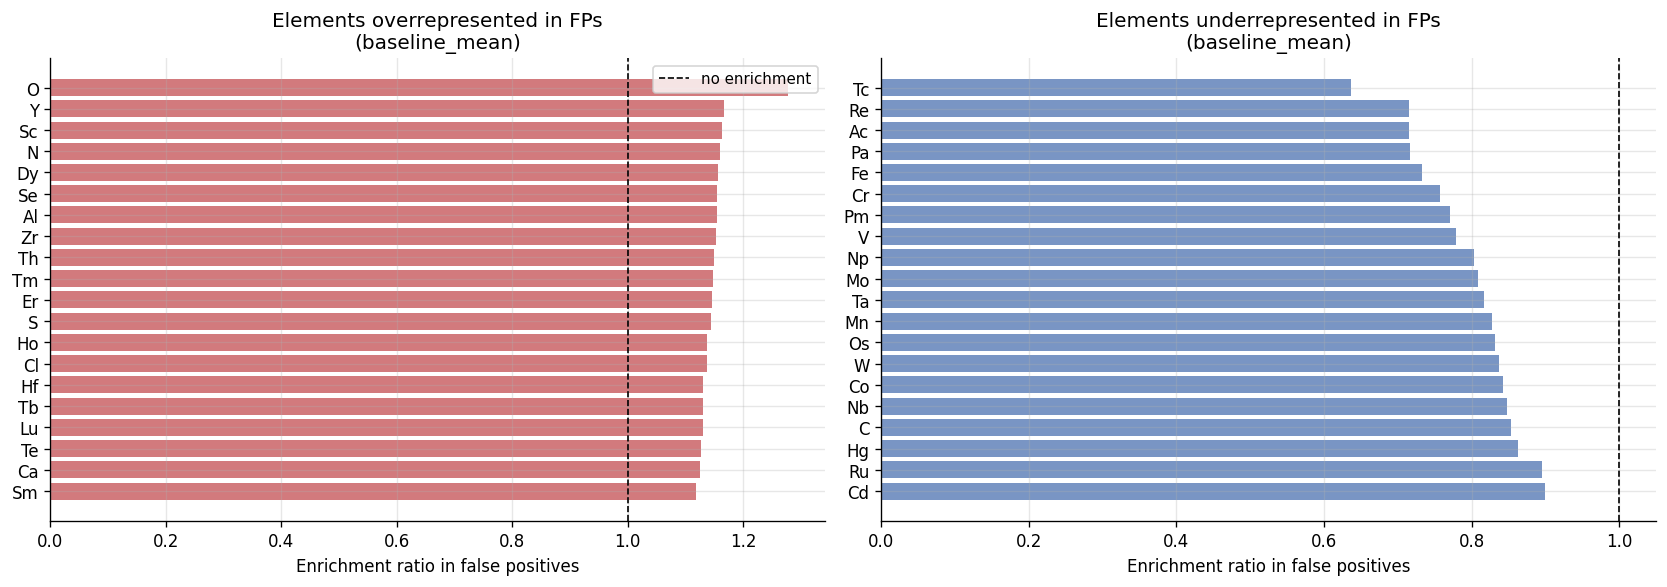

Saved: 05_element_enrichment_fp.png


In [10]:
# Element frequency in false positives vs full dataset
# Which elements are overrepresented in FPs?
name = 'baseline_mean'   # change to inspect other models
m = merged[name]

def count_elements(formulas):
    counter = Counter()
    for f in formulas:
        try:
            for el in Composition(f).elements:
                counter[str(el)] += 1
        except Exception:
            pass
    return counter

fp_elem  = count_elements(m.loc[m['fp'], 'formula'])
all_elem = count_elements(m['formula'])
n_fp     = m['fp'].sum()
n_all    = len(m)

# Enrichment ratio: (FP element freq) / (overall element freq)
enrichment = {}
for el, cnt in fp_elem.items():
    if all_elem[el] > 100:   # only elements with enough statistics
        enrichment[el] = (cnt / n_fp) / (all_elem[el] / n_all)

top_enriched   = sorted(enrichment.items(), key=lambda x: -x[1])[:20]
top_depleted   = sorted(enrichment.items(), key=lambda x:  x[1])[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

els, vals = zip(*top_enriched)
ax1.barh(list(reversed(els)), list(reversed(vals)), color=RED, alpha=0.75)
ax1.axvline(1.0, color='black', lw=1, ls='--', label='no enrichment')
ax1.set_xlabel('Enrichment ratio in false positives')
ax1.set_title(f'Elements overrepresented in FPs\n({name})')
ax1.legend(fontsize=9)

els, vals = zip(*top_depleted)
ax2.barh(list(reversed(els)), list(reversed(vals)), color=BLUE, alpha=0.75)
ax2.axvline(1.0, color='black', lw=1, ls='--')
ax2.set_xlabel('Enrichment ratio in false positives')
ax2.set_title(f'Elements underrepresented in FPs\n({name})')

fig.tight_layout()
fig.savefig(OUT_DIR / '05_element_enrichment_fp.png', dpi=150)
plt.show()
print('Saved: 05_element_enrichment_fp.png')

## Section 4 — Prediction error vs structure complexity

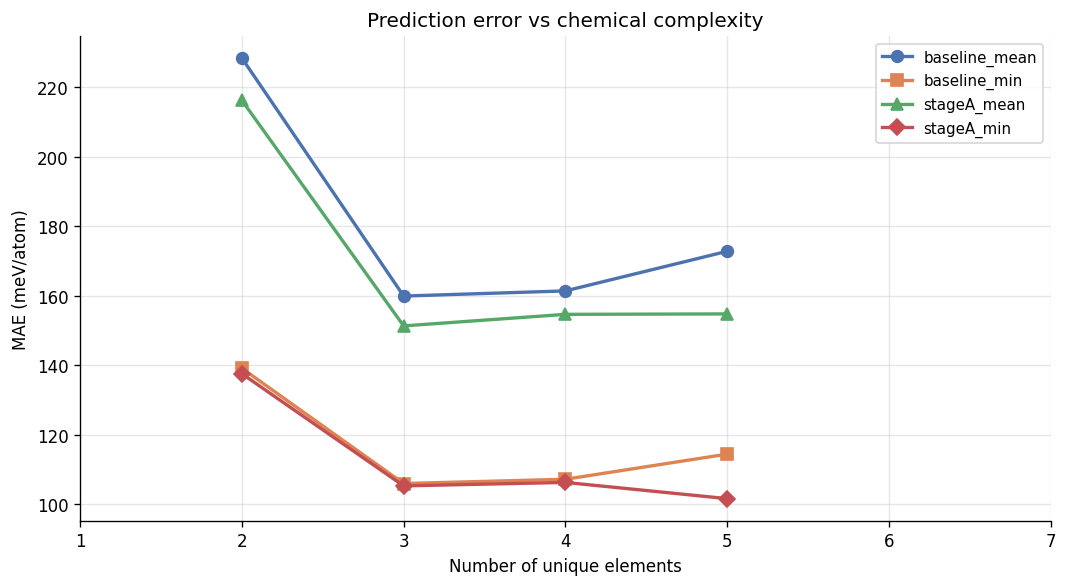

Saved: 06_mae_vs_nelements.png


In [11]:
# MAE vs n_unique_elements — all four models
fig, ax = plt.subplots(figsize=(9, 5))
elem_range = range(1, 8)

for (name, m), color, marker in zip(merged.items(), colors, ['o','s','^','D']):
    mae_by_el = []
    for n in elem_range:
        sub = m[m['n_unique_elements'] == n]
        mae_by_el.append(sub['abs_error'].mean() * 1000 if len(sub) > 0 else np.nan)
    ax.plot(list(elem_range), mae_by_el, color=color, marker=marker,
            lw=2, ms=7, label=name)

ax.set_xlabel('Number of unique elements')
ax.set_ylabel('MAE (meV/atom)')
ax.set_title('Prediction error vs chemical complexity')
ax.legend(fontsize=9)
ax.set_xticks(list(elem_range))
fig.tight_layout()
fig.savefig(OUT_DIR / '06_mae_vs_nelements.png', dpi=150)
plt.show()
print('Saved: 06_mae_vs_nelements.png')

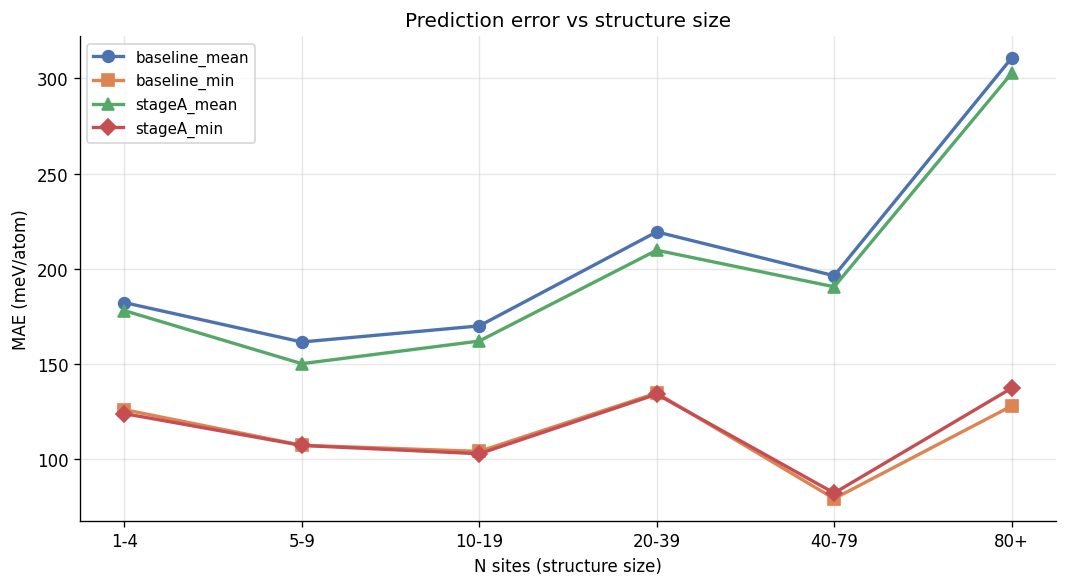

Saved: 07_mae_vs_nsites.png


In [12]:
# MAE vs n_sites — all four models
fig, ax = plt.subplots(figsize=(9, 5))
site_bins  = [1, 5, 10, 20, 40, 80, 200]
site_labels = ['1-4', '5-9', '10-19', '20-39', '40-79', '80+']

for (name, m), color, marker in zip(merged.items(), colors, ['o','s','^','D']):
    m2 = m.copy()
    m2['size_bin'] = pd.cut(m2['n_sites'], bins=site_bins, labels=site_labels, right=False)
    mae_by_size = m2.groupby('size_bin', observed=True)['abs_error'].mean() * 1000
    ax.plot(range(len(mae_by_size)), mae_by_size.values,
            color=color, marker=marker, lw=2, ms=7, label=name)

ax.set_xticks(range(len(site_labels)))
ax.set_xticklabels(site_labels)
ax.set_xlabel('N sites (structure size)')
ax.set_ylabel('MAE (meV/atom)')
ax.set_title('Prediction error vs structure size')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / '07_mae_vs_nsites.png', dpi=150)
plt.show()
print('Saved: 07_mae_vs_nsites.png')

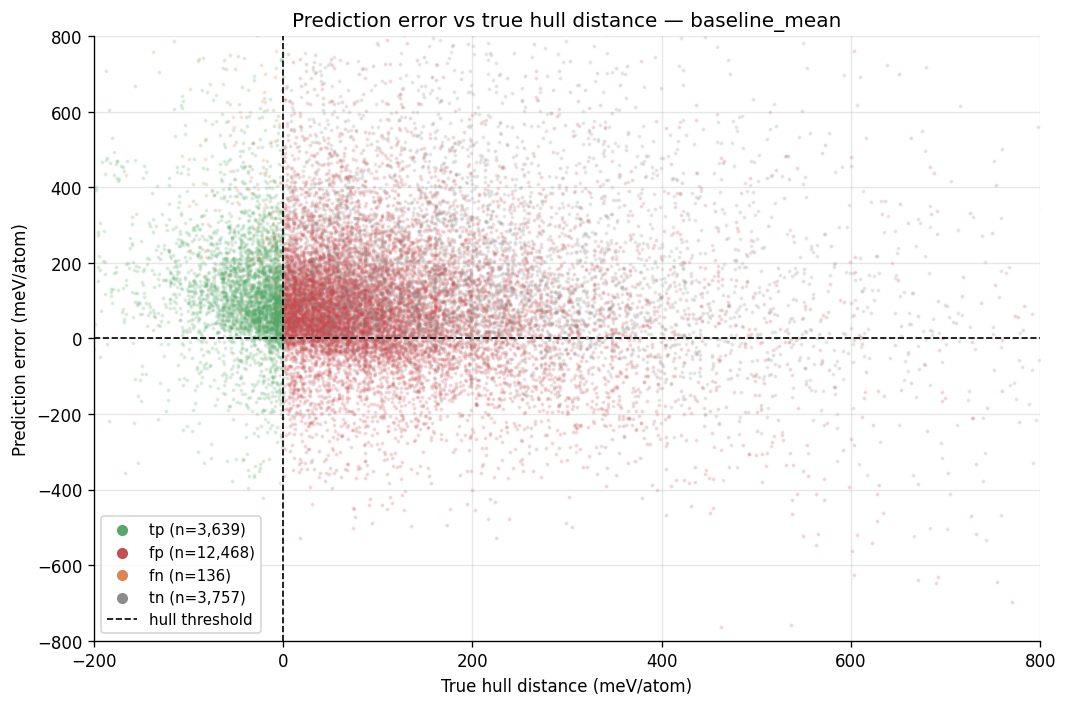

Saved: 08_error_vs_hull.png


In [13]:
# Scatter: prediction error vs true hull distance (baseline_mean)
# This tells us: does the model fail more on near-stable or unstable structures?
name = 'baseline_mean'
m = merged[name]

# Subsample for plotting speed
sample = m.sample(min(20000, len(m)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

# Color by TP/FP/FN/TN
cmap = {'tp': GREEN, 'fp': RED, 'fn': ORANGE, 'tn': GREY}
for label, color in cmap.items():
    sub = sample[sample[label]]
    ax.scatter(sub['e_above_hull_wbm'] * 1000,
               sub['error'] * 1000,
               c=color, alpha=0.15, s=2, label=f'{label} (n={sub[label].sum():,})')

ax.axhline(0, color='black', lw=1, ls='--')
ax.axvline(0, color='black', lw=1, ls='--', label='hull threshold')
ax.set_xlim(-200, 800)
ax.set_ylim(-800, 800)
ax.set_xlabel('True hull distance (meV/atom)')
ax.set_ylabel('Prediction error (meV/atom)')
ax.set_title(f'Prediction error vs true hull distance — {name}')
legend = ax.legend(fontsize=9, markerscale=4)
for lh in legend.legend_handles:
    lh.set_alpha(1)
fig.tight_layout()
fig.savefig(OUT_DIR / '08_error_vs_hull.png', dpi=150)
plt.show()
print('Saved: 08_error_vs_hull.png')

## Section 5 — TTA effect per structure

In [14]:
# Compare mean vs min TTA for baseline
# Which structures changed classification?
if 'baseline_mean' in merged and 'baseline_min' in merged:
    mean_df = merged['baseline_mean'][['material_id', 'e_form_pred', 'pred_stable',
                                        'tp', 'fp', 'fn', 'tn',
                                        'e_above_hull_wbm', 'true_stable',
                                        'n_unique_elements', 'n_sites']].copy()
    mean_df = mean_df.rename(columns={
        'e_form_pred': 'pred_mean', 'pred_stable': 'stable_mean',
        'tp': 'tp_mean', 'fp': 'fp_mean', 'fn': 'fn_mean', 'tn': 'tn_mean'
    })

    min_df = merged['baseline_min'][['material_id', 'e_form_pred', 'pred_stable',
                                      'tp', 'fp', 'fn', 'tn']].copy()
    min_df = min_df.rename(columns={
        'e_form_pred': 'pred_min', 'pred_stable': 'stable_min',
        'tp': 'tp_min', 'fp': 'fp_min', 'fn': 'fn_min', 'tn': 'tn_min'
    })

    comp = mean_df.merge(min_df, on='material_id')
    comp['pred_delta'] = (comp['pred_min'] - comp['pred_mean']) * 1000  # meV/atom

    # Structures that flipped classification
    flipped = comp[comp['stable_mean'] != comp['stable_min']]
    print(f'Structures that changed classification mean→min TTA: {len(flipped):,}')

    gained_stable = comp[~comp['stable_mean'] & comp['stable_min']]   # mean=unstable, min=stable
    lost_stable   = comp[ comp['stable_mean'] & ~comp['stable_min']]  # mean=stable,   min=unstable
    print(f'  Gained stable with min-TTA : {len(gained_stable):,}')
    print(f'  Lost stable with min-TTA   : {len(lost_stable):,}')

Structures that changed classification mean→min TTA: 23,761
  Gained stable with min-TTA : 23,761
  Lost stable with min-TTA   : 0


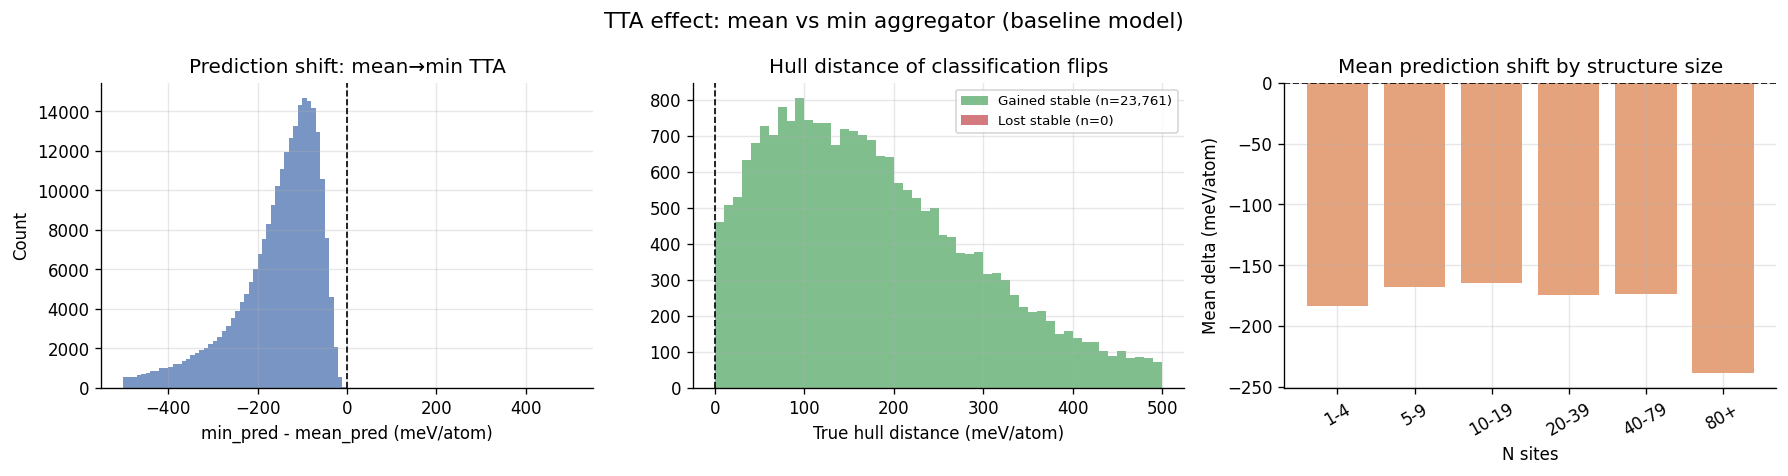

Saved: 09_tta_comparison.png


In [15]:
if 'baseline_mean' in merged and 'baseline_min' in merged:
    # Prediction delta distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(comp['pred_delta'], bins=100, range=(-500, 500), color=BLUE, alpha=0.75)
    axes[0].axvline(0, color='black', lw=1, ls='--')
    axes[0].set_xlabel('min_pred - mean_pred (meV/atom)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Prediction shift: mean→min TTA')

    # Hull distance of gained-stable vs lost-stable
    axes[1].hist(gained_stable['e_above_hull_wbm'] * 1000,
                 bins=50, range=(0, 500), color=GREEN, alpha=0.75,
                 label=f'Gained stable (n={len(gained_stable):,})')
    axes[1].hist(lost_stable['e_above_hull_wbm'] * 1000,
                 bins=50, range=(0, 500), color=RED, alpha=0.75,
                 label=f'Lost stable (n={len(lost_stable):,})')
    axes[1].axvline(0, color='black', lw=1, ls='--')
    axes[1].set_xlabel('True hull distance (meV/atom)')
    axes[1].set_title('Hull distance of classification flips')
    axes[1].legend(fontsize=8)

    # Delta by n_sites
    comp2 = comp.copy()
    comp2['size_bin'] = pd.cut(comp2['n_sites'], bins=site_bins, labels=site_labels, right=False)
    delta_by_size = comp2.groupby('size_bin', observed=True)['pred_delta'].mean()
    axes[2].bar(range(len(delta_by_size)), delta_by_size.values, color=ORANGE, alpha=0.75)
    axes[2].axhline(0, color='black', lw=1, ls='--')
    axes[2].set_xticks(range(len(site_labels)))
    axes[2].set_xticklabels(site_labels, rotation=30)
    axes[2].set_xlabel('N sites')
    axes[2].set_ylabel('Mean delta (meV/atom)')
    axes[2].set_title('Mean prediction shift by structure size')

    fig.suptitle('TTA effect: mean vs min aggregator (baseline model)', fontsize=13)
    fig.tight_layout()
    fig.savefig(OUT_DIR / '09_tta_comparison.png', dpi=150)
    plt.show()
    print('Saved: 09_tta_comparison.png')

## Section 6 — Summary table

In [16]:
rows = []
for name, m in merged.items():
    tp = m['tp'].sum(); fp = m['fp'].sum()
    fn = m['fn'].sum(); tn = m['tn'].sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    mae  = m['abs_error'].mean() * 1000
    bias = m['error'].mean() * 1000

    fp_df = m[m['fp']]
    fp_mean_hull  = fp_df['e_above_hull_wbm'].mean() * 1000 if len(fp_df) > 0 else np.nan
    fp_near       = (fp_df['e_above_hull_wbm'] * 1000 <= 50).sum()
    fp_near_pct   = 100 * fp_near / len(fp_df) if len(fp_df) > 0 else np.nan
    fp_mean_el    = fp_df['n_unique_elements'].mean() if len(fp_df) > 0 else np.nan

    rows.append({
        'model'              : name,
        'F1'                 : round(f1,   4),
        'Precision'          : round(prec, 4),
        'Recall'             : round(rec,  4),
        'MAE (meV)'          : round(mae,  1),
        'Bias (meV)'         : round(bias, 1),
        'N_FP'               : fp,
        'FP_mean_hull (meV)' : round(fp_mean_hull, 1),
        'FP_near_stable_%'   : round(fp_near_pct, 1),
        'FP_mean_nelements'  : round(fp_mean_el, 2),
    })

summary_df = pd.DataFrame(rows).set_index('model')
print('\n=== Full diagnosis summary ===')
display(summary_df)

summary_df.to_csv(OUT_DIR / '10_diagnosis_summary.csv')
print('Saved: 10_diagnosis_summary.csv')


=== Full diagnosis summary ===


,F1,Precision,Recall,MAE (meV),Bias (meV),N_FP,FP_mean_hull (meV),FP_near_stable_%,FP_mean_nelements
model,,,,,,,,,
baseline_mean,0.3645,0.2248,0.9637,168.8,122.5,160468,126.4,31.5,3.10
baseline_min,0.3436,0.2077,0.9930,110.3,-47.9,182816,134.8,29.2,3.07
stageA_mean,0.3631,0.2234,0.9697,159.9,110.8,162732,127.1,31.3,3.10
stageA_min,0.3432,0.2074,0.9930,109.4,-47.6,183161,134.9,29.2,3.06


Saved: 10_diagnosis_summary.csv


In [17]:
# Final interpretation print
print('=== Key diagnostic questions ===')
for name, m in merged.items():
    fp_df = m[m['fp']]
    near  = (fp_df['e_above_hull_wbm'] * 1000 <= 50).sum()
    far   = (fp_df['e_above_hull_wbm'] * 1000 > 200).sum()
    total = len(fp_df)
    print(f'\n{name}:')
    print(f'  Total FPs            : {total:,}')
    print(f'  Near-stable (≤50meV) : {near:,} ({100*near/max(total,1):.1f}%)')
    print(f'  Clearly unstable >200: {far:,} ({100*far/max(total,1):.1f}%)')
    print(f'  Verdict: ', end='')
    if 100*near/max(total,1) > 50:
        print('Majority of FPs are near-stable — better data/AL could fix this.')
    elif 100*far/max(total,1) > 50:
        print('Majority of FPs are clearly unstable — model has poor discriminative power.')
    else:
        print('Mixed FP distribution — both data and model contribute.')

=== Key diagnostic questions ===

baseline_mean:
  Total FPs            : 160,468
  Near-stable (≤50meV) : 50,540 (31.5%)
  Clearly unstable >200: 30,091 (18.8%)
  Verdict: Mixed FP distribution — both data and model contribute.

baseline_min:
  Total FPs            : 182,816
  Near-stable (≤50meV) : 53,376 (29.2%)
  Clearly unstable >200: 38,859 (21.3%)
  Verdict: Mixed FP distribution — both data and model contribute.

stageA_mean:
  Total FPs            : 162,732
  Near-stable (≤50meV) : 50,885 (31.3%)
  Clearly unstable >200: 30,902 (19.0%)
  Verdict: Mixed FP distribution — both data and model contribute.

stageA_min:
  Total FPs            : 183,161
  Near-stable (≤50meV) : 53,400 (29.2%)
  Clearly unstable >200: 39,043 (21.3%)
  Verdict: Mixed FP distribution — both data and model contribute.
